# Ejercicio de programación - Regresión Logística Binaria

En este ejercicio se implementa regresión logística binaria aplicada al dataset **BRFSS 2020** (Behavioral Risk Factor Surveillance System) para predecir el riesgo de **diabetes** (`DIABETE4`).

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize
from sklearn.impute import SimpleImputer

## 1. Carga y Preprocesamiento de Datos

Se utiliza el dataset **BRFSS 2020**. La variable dependiente es `DIABETE4` (¿Alguna vez le dijeron que tiene diabetes?):
- `1` → Sí tiene diabetes
- `2`, `3`, `4` → No (pre-diabetes, solo en embarazo, o no)

La siguiente celda carga los datos **exactamente igual** al notebook de referencia `healthcare-risk-prediction`:

##Definición de X e Y

- **Y** (variable dependiente): `DIABETE4` → 1 = tiene diabetes, 0 = no tiene diabetes
- **X** (variables independientes): los demás predictores disponibles en el dataset

| Variable | Descripción |
|---|---|
| `INCOME2` | Nivel de ingresos |
| `_BMI5` | Índice de masa corporal |
| `_RFHLTH` | Salud general |
| `_PHYS14D` | Días con problemas físicos |
| `_MENT14D` | Días con problemas mentales |
| `CHECKUP1` | Último chequeo médico |
| `MARITAL` | Estado civil |
| `EDUCA` | Nivel educativo |
| `BIRTHSEX` | Sexo |
| `_RACE` | Raza |
| `_STATE` | Estado |
| `VETERAN3` | Veterano |
| `EMPLOY1` | Situación laboral |
| `HLTHPLN1` | Tiene plan de salud |

In [2]:
data=pd.read_csv('../Database/2_brfss2020.csv')
elim = data['DIABETE4'].map({1: 1, 2: 0, 3: 0, 4: 0}).notna()
X = data.loc[elim, ['MARITAL', 'EDUCA', 'INCOME2', '_BMI5', '_RACE','EMPLOY1', '_RFHLTH', '_PHYS14D', '_MENT14D', 'CHECKUP1']].copy()
y = data.loc[elim, 'DIABETE4'].map({1: 1, 2: 0, 3: 0, 4: 0})

# Para numéricas (mediana)
imputer_median = SimpleImputer(strategy='median')
X[['INCOME2', '_BMI5']] = imputer_median.fit_transform(X[['INCOME2', '_BMI5']])

# Para categóricas (moda)
imputer_mode = SimpleImputer(strategy='most_frequent')
cols_mode = ['MARITAL', 'EDUCA', '_RACE', 'EMPLOY1', '_RFHLTH','_PHYS14D', '_MENT14D', 'CHECKUP1']
X[cols_mode] = imputer_mode.fit_transform(X[cols_mode])
X=X.values
y=y.values

### 1.2 Visualizar los Datos

Antes de implementar el algoritmo, se visualizan los datos. Se grafica la distribución de la variable objetivo y la relación entre dos variables clave (Edad y BMI) diferenciando por clase.

Se completará el código en `plotData` para que muestre una figura donde los ejes son dos variables predictoras; los ejemplos positivos y negativos se muestran con diferentes marcadores.

In [3]:
def plotData(X, y):
    fig = pyplot.figure()
    pos = y == 1
    neg = y == 0
    # columna 3 = _BMI5 (indice 3), columna 7 = _PHYS14D (indice 7)
    pyplot.plot(X[pos, 3], X[pos, 7], "k*", lw=2, ms=10)
    pyplot.plot(X[neg, 3], X[neg, 7], "ko", mfc="y", ms=8, mec="k", mew=1)
    pyplot.xlabel("BMI (Índice de Masa Corporal)")
    pyplot.ylabel("Días de mala salud física")
    pyplot.title("BMI vs Salud Física por estado de diabetes")
    pyplot.legend(["Diabético", "No diabético"])
    pyplot.grid(False)
    pyplot.show()

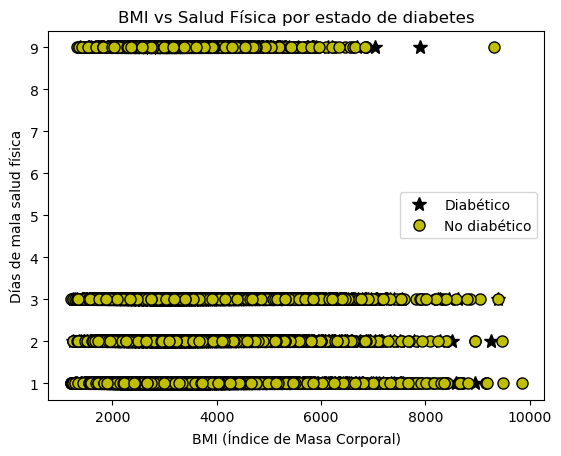

In [5]:
plotData(X, y)

## 2. Implementación de la Regresión Logística

### 2.1 Función Sigmoidea

La hipótesis para la regresión logística se define como:

$$ h_\theta(x) = g(\theta^T x) $$

donde la función $g$ es la función sigmoidea:

$$g(z) = \frac{1}{1+e^{-z}}$$

Para valores positivos grandes de `z` el resultado debe ser cercano a 1; para valores negativos grandes, cercano a 0; y `sigmoid(0) = 0.5`.

In [6]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

### 2.2 Función de Costo y Gradiente

Antes de continuar, se agrega el término de intercepción (columna de unos) a X.

La función de costo en regresión logística es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta(x^{(i)})\right) - \left(1-y^{(i)}\right) \log\left(1-h_\theta(x^{(i)})\right) \right] $$

Y el gradiente es:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)} $$

In [7]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agraga el termino de intercepción a A
X = np.concatenate([np.ones((m, 1)), X], axis=1)

In [ ]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [9]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

/tmp/ipykernel_21008/714609262.py:8: RuntimeWarning: overflow encountered in exp
  g = 1 / (1 + np.exp(-z))
/tmp/ipykernel_21008/2268448176.py:7: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))


theta calculado por el descenso por el gradiente: [-0.00151364 -0.00606772 -0.01067455 -0.03705168 -0.33950152 -0.00276277
  0.01177164  0.00115817  0.0022631  -0.00178491 -0.00641937]
Costo con theta encontrada:  nan


ValueError: shapes (3,) and (11,) not aligned: 3 (dim 0) != 11 (dim 0)

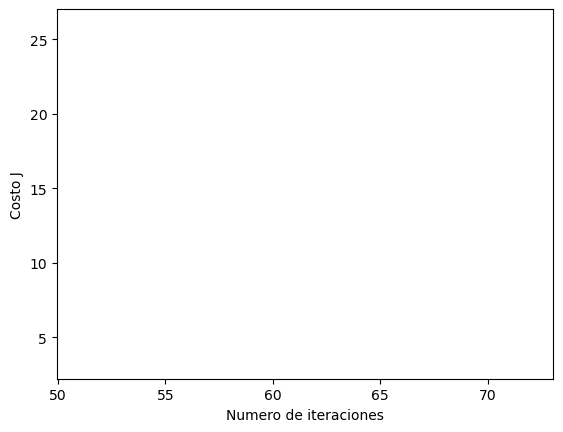

In [11]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 100

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(n+1)
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))
print('Costo con theta encontrada: ', calcularCosto(theta, X, y))

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')


# verificar si ingresa o no a la universidad
X_array = [1, 80, 46]
aprueba = sigmoid(np.dot(X_array, theta))   # Se debe cambiar esto

print('Un estudiante con nota del examen 1: 80 y nota del examen 2: 46 (usando el descenso por el gradiente):{:.0f}'.format(aprueba))

### 2.3 Parámetros de aprendizaje usando `scipy.optimize`

En lugar de solo usar descenso de gradiente manual, se utiliza `optimize.minimize` para encontrar los parámetros óptimos θ de forma más eficiente. Se utiliza el método TNC (Newton Conjugado Truncado).

In [ ]:
def costFunction(theta, X, y):
    m = y.size  # número de ejemplos de entrenamiento
    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

In [ ]:
# Inicialización de parámetros de ajuste
initial_theta = np.zeros(n + 1)
print(initial_theta)

cost, grad = costFunction(initial_theta, X, y)
print('Costo en theta inicial (zeros): {:.3f}'.format(cost))
print('Gradiente en theta inicial:')
print(grad)

In [ ]:
# Establecer las opciones para optimize.minimize
options = {'maxiter': 1000}

# Se utiliza el algoritmo de Newton truncado para la optimización
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

# La propiedad fun contiene el costo con theta optimizado
cost = res.fun

# Theta optimizada está en la propiedad x
theta = res.x

print('Costo con theta encontrado por optimize.minimize: {:.4f}'.format(cost))
print('\nTheta optimizado:')
print(theta)

### 2.4 Evaluación de la Regresión Logística

Una vez entrenado el modelo, se procede a la predicción y evaluación sobre el conjunto de entrenamiento.

In [ ]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 o 1 mediante regresión logística aprendida.
    Calcula las predicciones para X usando un umbral en 0.5
    (si sigmoid(theta.T * x) >= 0.5, predice 1).

    Parámetros
    ----------
    theta : array_like
        Parámetros para regresión logística. Un vector de la forma (n+1, ).
    X : array_like
        Datos para el cálculo de las predicciones.

    Devuelve
    -------
    p : array_like
        Predicciones 0 o 1 para cada fila en X.
    """
    m = X.shape[0]  # Número de ejemplos de entrenamiento
    p = np.zeros(m)
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

In [ ]:
# Predicción de probabilidad para un perfil de ejemplo
# Orden de columnas: INCOME2, _BMI5, _RFHLTH, _PHYS14D, _MENT14D, CHECKUP1,
#                    MARITAL, EDUCA, BIRTHSEX, _RACE, _STATE, VETERAN3, EMPLOY1, HLTHPLN1
# Ejemplo: ingresos medios, BMI=280, buena salud, 0 días físicos, 0 mentales, chequeo reciente
ejemplo = np.array([1,  5, 280, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1])
prob = sigmoid(np.dot(ejemplo, theta))
print('Probabilidad de diabetes para el perfil de ejemplo: {:.3f}'.format(prob))

# Precisión sobre el conjunto de entrenamiento
p = predict(theta, X)
print('Precisión de entrenamiento: {:.2f} %'.format(np.mean(p == y) * 100))

## 3. Conclusión

Se aplicó regresión logística binaria al dataset BRFSS 2020 para predecir el riesgo de **diabetes** (`DIABETE4`).

Los pasos realizados fueron:
1. Carga y limpieza de datos usando `load_and_clean_brfss_data()` exactamente igual al notebook de referencia
2. Definición de **Y** = `DIABETE4` (1=diabético, 0=no diabético) y **X** = 14 predictores codificados
3. Implementación manual de: función sigmoide, función de costo, descenso de gradiente
4. Optimización con `scipy.optimize.minimize` (método TNC)
5. Evaluación mediante precisión de entrenamiento

> ⚠️ **Nota**: El dataset está desbalanceado (muchos más no diabéticos que diabéticos). Se recomienda explorar técnicas de remuestreo o ajuste de pesos para mejorar la detección de casos positivos.